# EDA — Sols 1–100
## Pressure vs Local Mean Solar Time

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path(r"C:\Users\Anwender\Documents\Weiterbildung Stackfuel\Portfolio\Data\CAL")

df = pd.read_csv(DATA_DIR / "CAL_PS _SOL_01_100.csv")
print(df.shape)
df.head()

(4066235, 16)


,SCLK,LMST,LTST,BAROCAP1_PRESSURE,BAROCAP1_PRESSURE_UNCERTAINTY,BAROCAP2_PRESSURE,BAROCAP2_PRESSURE_UNCERTAINTY,BAROCAP3_PRESSURE,BAROCAP3_PRESSURE_UNCERTAINTY,THERMOCAP1_TEMP,THERMOCAP1_TEMP_UNCERTAINTY,THERMOCAP2_TEMP,THERMOCAP2_TEMP_UNCERTAINTY,PRESSURE_MEASUREMENT_MODE,TRANSDUCER,sol
0,667042464,00001M16:05:31.315,0001 15:28:01,715.96,NaN,715.84,NaN,0.0,NaN,298.28,NaN,298.31,NaN,nominal,2,1
1,667042465,00001M16:05:32.289,0001 15:28:02,715.82,NaN,715.64,NaN,0.0,NaN,298.27,NaN,298.30,NaN,nominal,2,1
2,667042466,00001M16:05:33.262,0001 15:28:03,715.99,NaN,715.58,NaN,0.0,NaN,298.28,NaN,298.31,NaN,nominal,2,1
3,667042467,00001M16:05:34.235,0001 15:28:04,715.92,NaN,715.51,NaN,0.0,NaN,298.28,NaN,298.31,NaN,nominal,2,1
4,667042468,00001M16:05:35.208,0001 15:28:05,715.77,NaN,715.65,NaN,0.0,NaN,298.29,NaN,298.31,NaN,nominal,2,1


In [3]:
# parse LMST: format is SSSSSM HH:MM:SS.fff — split on "M" to get time-of-sol
df["LMST_time"] = pd.to_datetime(
    df["LMST"].str.split("M").str[1],
    format="%H:%M:%S.%f"
)

df.head(3)[["LMST", "LMST_time", "BAROCAP1_PRESSURE"]]

,LMST,LMST_time,BAROCAP1_PRESSURE
0,00001M16:05:31.315,1900-01-01 16:05:31.315,715.96
1,00001M16:05:32.289,1900-01-01 16:05:32.289,715.82
2,00001M16:05:33.262,1900-01-01 16:05:33.262,715.99


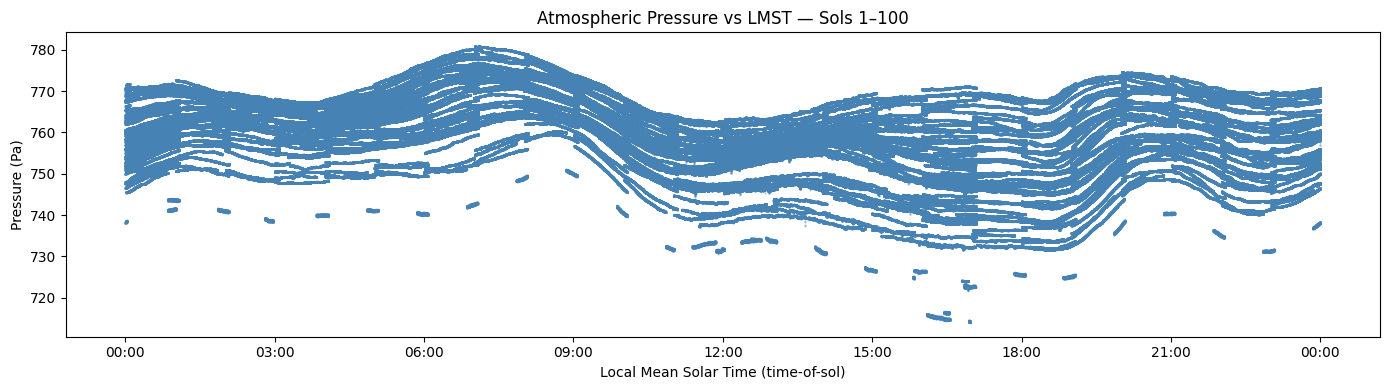

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.scatter(df["LMST_time"], df["BAROCAP1_PRESSURE"], s=0.5, alpha=0.3, color="steelblue")

ax.set_xlabel("Local Mean Solar Time (time-of-sol)")
ax.set_ylabel("Pressure (Pa)")
ax.set_title("Atmospheric Pressure vs LMST — Sols 1–100")

# format x-axis as HH:MM
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.show()

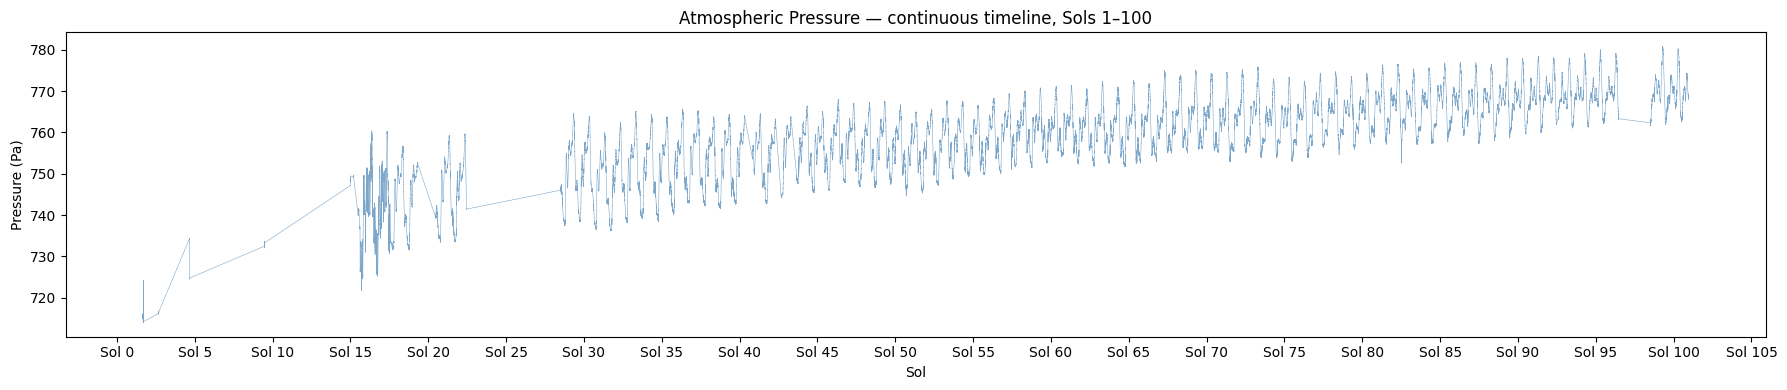

In [5]:
# fractional sol: sol number + fraction of day from LMST time-of-sol
lmst_time = pd.to_datetime(df["LMST"].str.split("M").str[1], format="%H:%M:%S.%f")
day_fraction = (lmst_time.dt.hour + lmst_time.dt.minute / 60 + lmst_time.dt.second / 3600) / 24
df["sol_continuous"] = df["sol"] + day_fraction

fig, ax = plt.subplots(figsize=(18, 4))

ax.plot(df["sol_continuous"], df["BAROCAP1_PRESSURE"], lw=0.4, alpha=0.7, color="steelblue")

ax.set_xlabel("Sol")
ax.set_ylabel("Pressure (Pa)")
ax.set_title("Atmospheric Pressure — continuous timeline, Sols 1–100")

import matplotlib.ticker as ticker
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"Sol {int(x)}"))

plt.tight_layout()
plt.show()

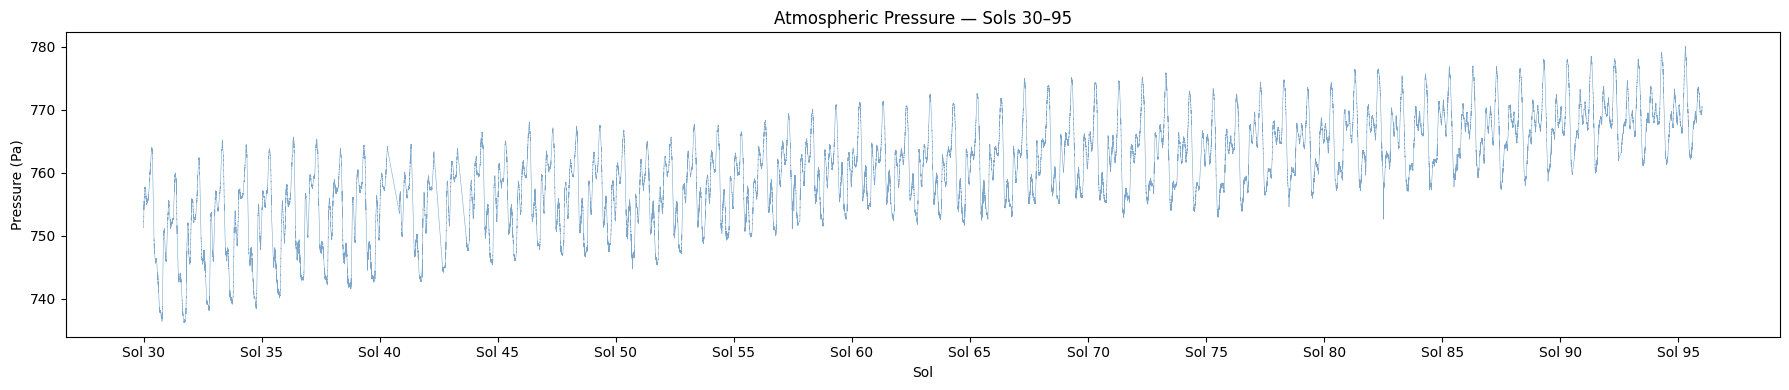

In [6]:
df_focus = df[(df["sol"] >= 30) & (df["sol"] <= 95)]

fig, ax = plt.subplots(figsize=(18, 4))

ax.plot(df_focus["sol_continuous"], df_focus["BAROCAP1_PRESSURE"], lw=0.4, alpha=0.7, color="steelblue")

ax.set_xlabel("Sol")
ax.set_ylabel("Pressure (Pa)")
ax.set_title("Atmospheric Pressure — Sols 30–95")

import matplotlib.ticker as ticker
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"Sol {int(x)}"))

plt.tight_layout()
plt.show()

## RDS — Radiation & Dust Sensor

16 photodiode channels measuring upwelling irradiance (W/m²):
- **RDS_TOP_1–8**: photodiodes facing upward (downwelling solar radiation)
- **RDS_LAT_1–8**: photodiodes on the sides (lateral irradiance)
- **_HG variants**: same channels in high-gain mode (low-light conditions)

Plotted vs LMST time-of-sol to see the daily solar cycle.

In [7]:
rds_raw = pd.read_csv(DATA_DIR / "CAL_RDS _SOL_01_100.csv")
rds = rds_raw[(rds_raw["sol"] >= 30) & (rds_raw["sol"] <= 95)].copy()

# fractional hour of sol for x-axis (0–24 h)
lmst_time = pd.to_datetime(rds["LMST"].str.split("M").str[1], format="%H:%M:%S.%f")
rds["hour_of_sol"] = lmst_time.dt.hour + lmst_time.dt.minute / 60 + lmst_time.dt.second / 3600

print(f"Rows: {len(rds):,}  |  Sols: {rds['sol'].min()}–{rds['sol'].max()}")
rds.head(3)

Rows: 3,539,467  |  Sols: 30–95


,SCLK,LMST,LTST,RDS_LAT_1,RDS_LAT_2,RDS_LAT_3,RDS_LAT_4,RDS_LAT_5,RDS_LAT_6,RDS_LAT_7,...,RDS_TOP_3_HG,RDS_TOP_4_HG,RDS_TOP_5_HG,RDS_TOP_6_HG,RDS_TOP_7_HG,RDS_TOP_8_HG,ROVER_HGA_STILL,ROVER_STILL,sol,hour_of_sol
376384,669557403,00030M00:00:00.651,0029 23:32:27,3.013000e-11,0.000027,0.000057,0.000013,0.000123,0.000006,0.000062,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,30,0.000000
376385,669557404,00030M00:00:01.625,0029 23:32:28,2.958800e-11,0.000027,0.000050,0.000012,0.000128,0.000011,0.000064,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,30,0.000278
376386,669557405,00030M00:00:02.598,0029 23:32:29,2.844900e-11,0.000023,0.000056,0.000013,0.000126,0.000015,0.000066,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,30,0.000556


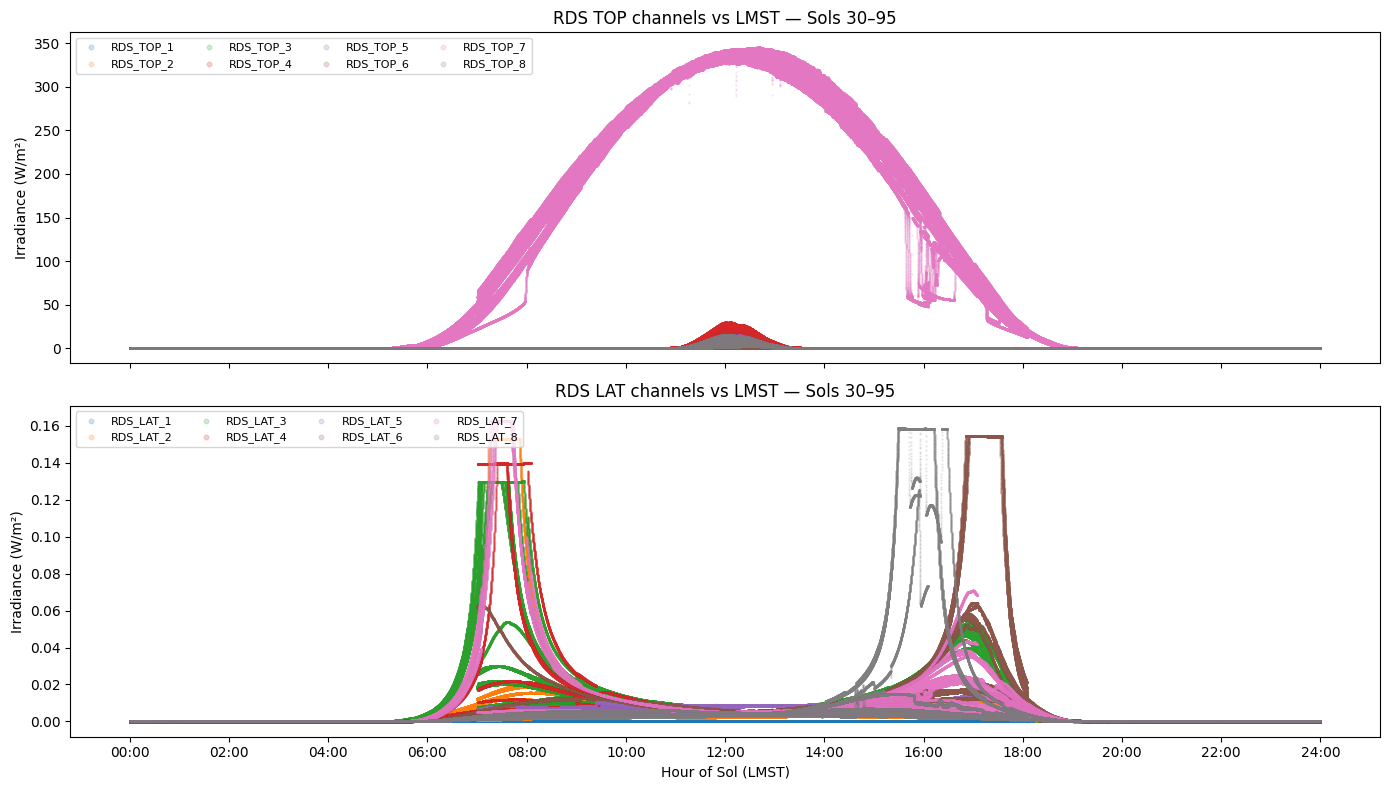

In [8]:
top_cols = [f"RDS_TOP_{i}" for i in range(1, 9)]
lat_cols = [f"RDS_LAT_{i}" for i in range(1, 9)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# TOP channels
for col in top_cols:
    axes[0].scatter(rds["hour_of_sol"], rds[col], s=0.3, alpha=0.2, label=col)
axes[0].set_ylabel("Irradiance (W/m²)")
axes[0].set_title("RDS TOP channels vs LMST — Sols 30–95")
axes[0].legend(loc="upper left", markerscale=6, ncol=4, fontsize=8)

# LAT channels
for col in lat_cols:
    axes[1].scatter(rds["hour_of_sol"], rds[col], s=0.3, alpha=0.2, label=col)
axes[1].set_ylabel("Irradiance (W/m²)")
axes[1].set_title("RDS LAT channels vs LMST — Sols 30–95")
axes[1].set_xlabel("Hour of Sol (LMST)")
axes[1].legend(loc="upper left", markerscale=6, ncol=4, fontsize=8)

import matplotlib.ticker as ticker
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(2))
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):02d}:00"))

plt.tight_layout()
plt.show()

## WS — Wind Sensor

Two booms (BOOM1, BOOM2), each measuring:
- **Horizontal wind speed** (m/s)
- **Vertical wind speed** (m/s)
- **Wind direction** (degrees, 0–360)

Quality flags: `BOOM1/2_ALG_STATE_STABLE` and `ROVER_STILL` — filtering to stable + rover still gives the cleanest data.

Note: WS data starts at Sol 36 (sensor not active earlier).

In [9]:
ws_raw = pd.read_csv(DATA_DIR / "CAL_WS _SOL_01_100.csv")
ws = ws_raw[(ws_raw["sol"] >= 30) & (ws_raw["sol"] <= 95)].copy()

# quality filter: rover still + both booms algorithmically stable
ws_stable = ws[(ws["ROVER_STILL"] == 1) &
               (ws["BOOM1_ALG_STATE_STABLE"] == 1) &
               (ws["BOOM2_ALG_STATE_STABLE"] == 1)].copy()

lmst_time = pd.to_datetime(ws_stable["LMST"].str.split("M").str[1], format="%H:%M:%S.%f")
ws_stable["hour_of_sol"] = lmst_time.dt.hour + lmst_time.dt.minute / 60 + lmst_time.dt.second / 3600

print(f"All rows: {len(ws):,}  |  After quality filter: {len(ws_stable):,}")
print(f"Sol range: {ws_stable['sol'].min()}–{ws_stable['sol'].max()}")

All rows: 3,187,755  |  After quality filter: 3,101,753
Sol range: 36–95


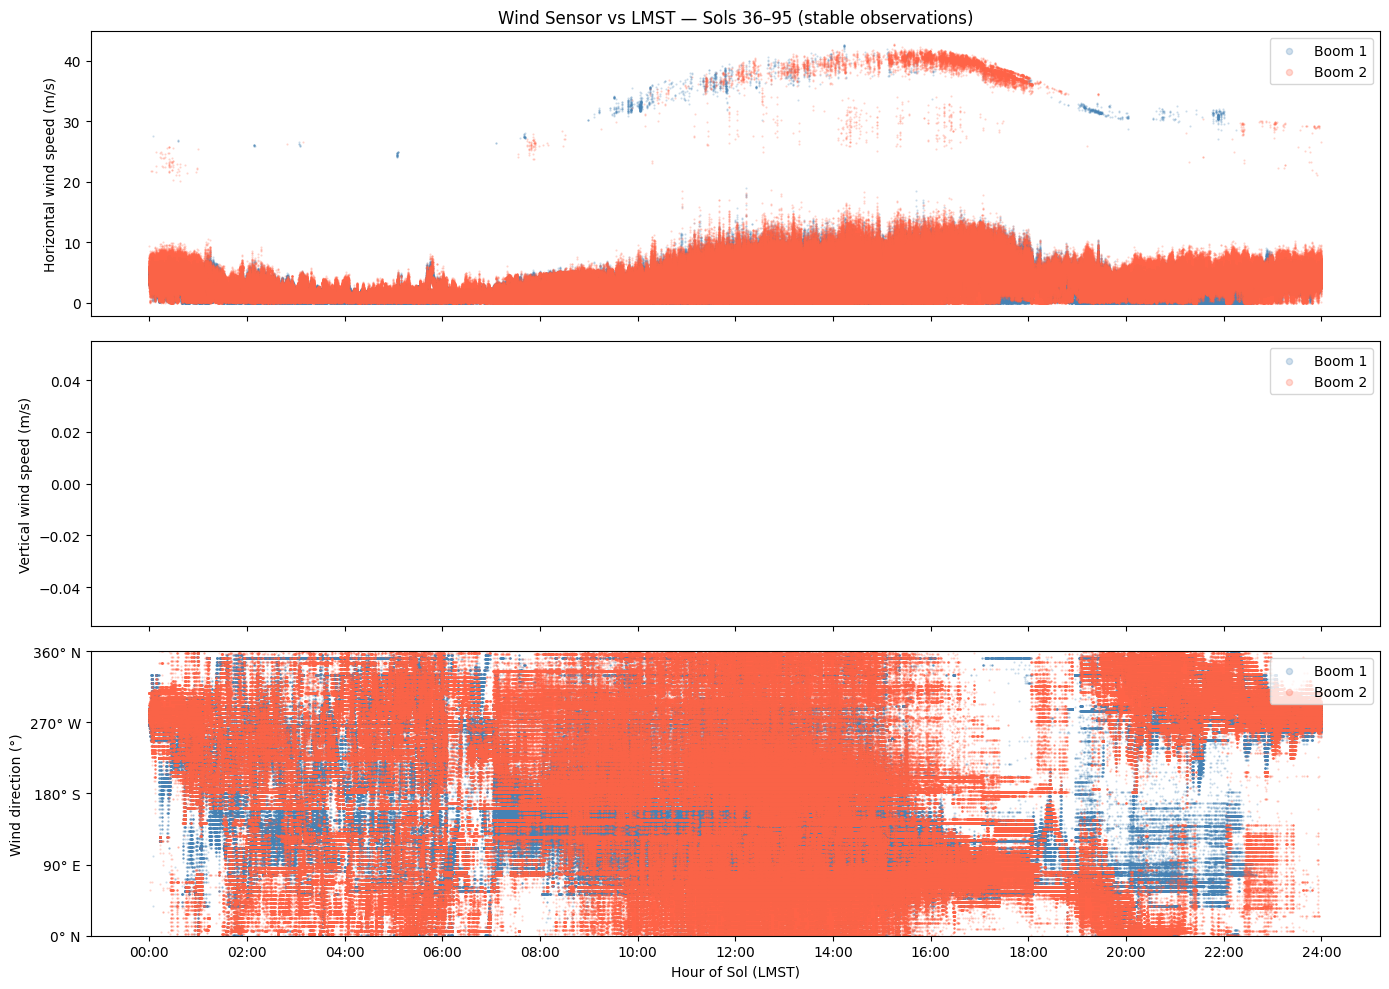

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

scatter_kw = dict(s=0.3, alpha=0.25)

# horizontal wind speed
axes[0].scatter(ws_stable["hour_of_sol"], ws_stable["BOOM1_HORIZONTAL_WIND_SPEED"], color="steelblue", label="Boom 1", **scatter_kw)
axes[0].scatter(ws_stable["hour_of_sol"], ws_stable["BOOM2_HORIZONTAL_WIND_SPEED"], color="tomato",    label="Boom 2", **scatter_kw)
axes[0].set_ylabel("Horizontal wind speed (m/s)")
axes[0].set_title("Wind Sensor vs LMST — Sols 36–95 (stable observations)")
axes[0].legend(loc="upper right", markerscale=8)

# vertical wind speed
axes[1].scatter(ws_stable["hour_of_sol"], ws_stable["BOOM1_VERTICAL_WIND_SPEED"], color="steelblue", label="Boom 1", **scatter_kw)
axes[1].scatter(ws_stable["hour_of_sol"], ws_stable["BOOM2_VERTICAL_WIND_SPEED"], color="tomato",    label="Boom 2", **scatter_kw)
axes[1].set_ylabel("Vertical wind speed (m/s)")
axes[1].legend(loc="upper right", markerscale=8)

# wind direction
axes[2].scatter(ws_stable["hour_of_sol"], ws_stable["BOOM1_WIND_DIRECTION"], color="steelblue", label="Boom 1", **scatter_kw)
axes[2].scatter(ws_stable["hour_of_sol"], ws_stable["BOOM2_WIND_DIRECTION"], color="tomato",    label="Boom 2", **scatter_kw)
axes[2].set_ylabel("Wind direction (°)")
axes[2].set_xlabel("Hour of Sol (LMST)")
axes[2].set_ylim(0, 360)
axes[2].set_yticks([0, 90, 180, 270, 360])
axes[2].set_yticklabels(["0° N", "90° E", "180° S", "270° W", "360° N"])
axes[2].legend(loc="upper right", markerscale=8)

import matplotlib.ticker as ticker
axes[2].xaxis.set_major_locator(ticker.MultipleLocator(2))
axes[2].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):02d}:00"))

plt.tight_layout()
plt.show()

## ATS — Air Temperature Sensor

5 boom-mounted thermometers (`ATS_LOCAL_TEMP1–5`) measuring atmospheric temperature in **Kelvin**.  
The booms are positioned at different heights and azimuths around the rover mast.

Two views:
- **Continuous timeline** (top) — shows both the daily cycle and any sol-to-sol seasonal drift
- **Daily cycle** (bottom) — all sols folded onto one 24 h axis, reveals the diurnal pattern

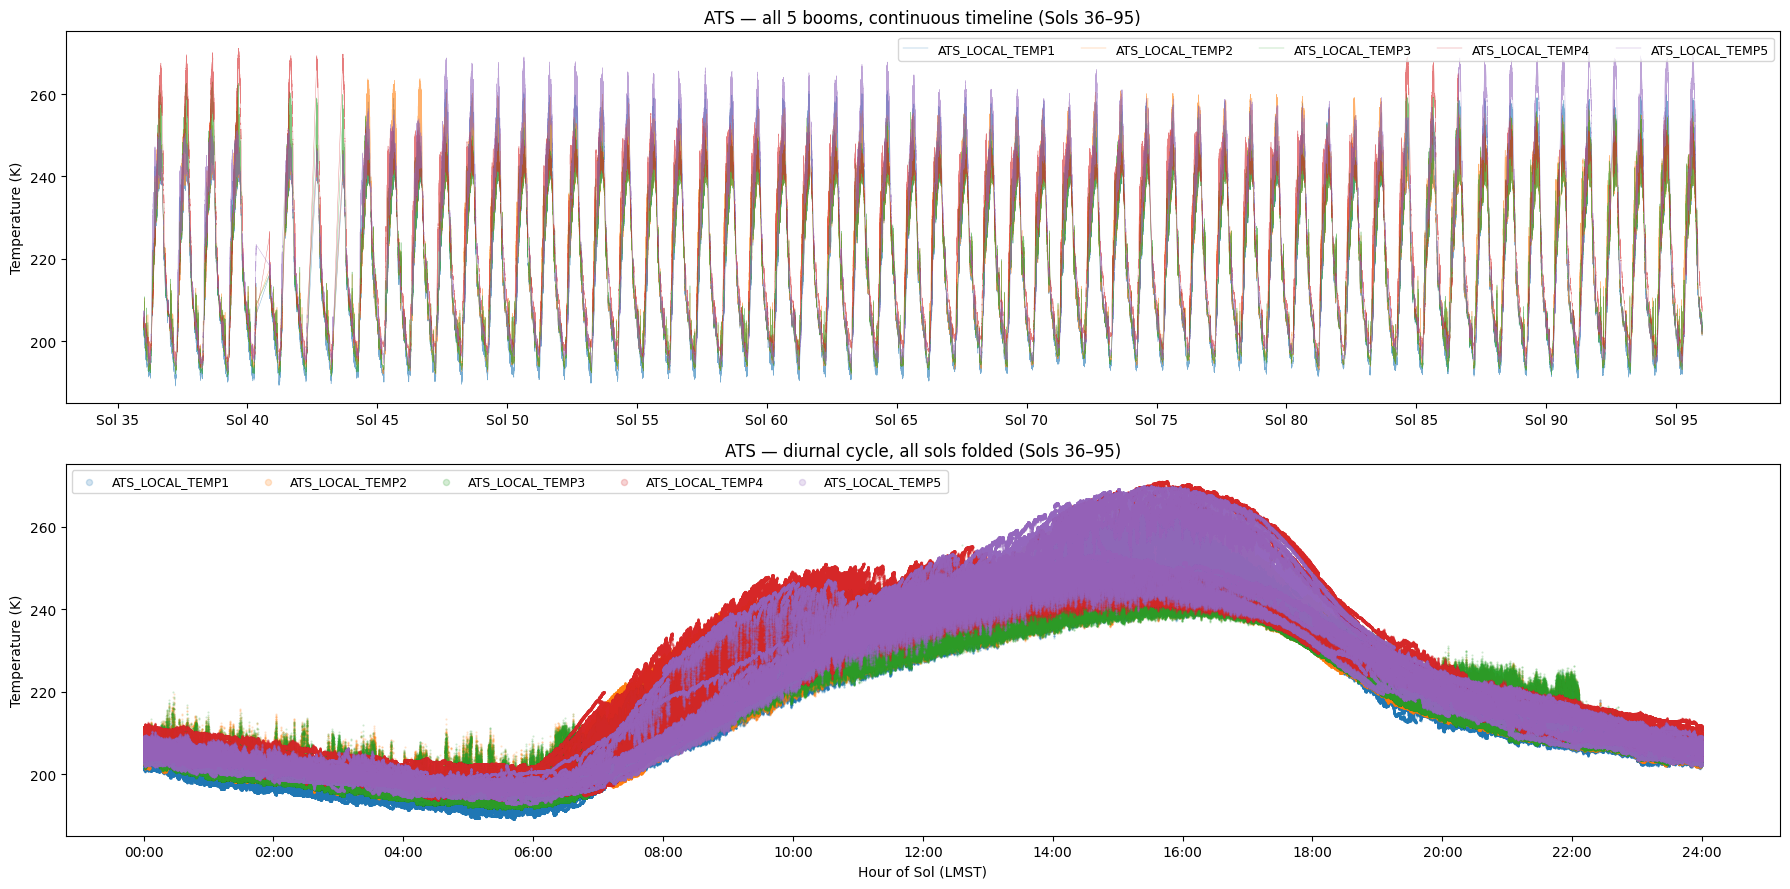

Rows: 6,477,617  |  Sols: 36–95
       ATS_LOCAL_TEMP1  ATS_LOCAL_TEMP2  ATS_LOCAL_TEMP3  ATS_LOCAL_TEMP4  \
count        6477617.0        6477617.0        6477617.0        6477617.0   
mean             218.7            220.4            218.9            223.2   
std               19.6             19.1             18.2             18.9   
min              189.1            191.9            191.4            193.4   
25%              201.6            202.8            202.5            205.1   
50%              214.1            218.0            215.6            220.3   
75%              237.8            238.7            237.2            242.0   
max              261.1            263.8            263.0            271.1   

       ATS_LOCAL_TEMP5  
count        6477617.0  
mean             222.4  
std               21.5  
min              192.7  
25%              202.5  
50%              217.0  
75%              243.1  
max              269.9  


In [11]:
ats_raw = pd.read_csv(DATA_DIR / "CAL_ATS _SOL_01_100.csv")
ats = ats_raw[(ats_raw["sol"] >= 36) & (ats_raw["sol"] <= 95)].copy()

lmst_time = pd.to_datetime(ats["LMST"].str.split("M").str[1], format="%H:%M:%S.%f")
ats["hour_of_sol"]    = lmst_time.dt.hour + lmst_time.dt.minute / 60 + lmst_time.dt.second / 3600
day_fraction          = ats["hour_of_sol"] / 24
ats["sol_continuous"] = ats["sol"] + day_fraction

TEMP_COLS   = [f"ATS_LOCAL_TEMP{i}" for i in range(1, 6)]
colors      = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

import matplotlib.ticker as ticker

fig, axes = plt.subplots(2, 1, figsize=(18, 9))

# --- continuous timeline ---
for col, c in zip(TEMP_COLS, colors):
    axes[0].plot(ats["sol_continuous"], ats[col], lw=0.3, alpha=0.6, color=c, label=col)
axes[0].set_ylabel("Temperature (K)")
axes[0].set_title("ATS — all 5 booms, continuous timeline (Sols 36–95)")
axes[0].legend(loc="upper right", ncol=5, fontsize=9)
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(5))
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"Sol {int(x)}"))

# --- daily cycle ---
scatter_kw = dict(s=0.3, alpha=0.2)
for col, c in zip(TEMP_COLS, colors):
    axes[1].scatter(ats["hour_of_sol"], ats[col], color=c, label=col, **scatter_kw)
axes[1].set_ylabel("Temperature (K)")
axes[1].set_xlabel("Hour of Sol (LMST)")
axes[1].set_title("ATS — diurnal cycle, all sols folded (Sols 36–95)")
axes[1].legend(loc="upper left", ncol=5, fontsize=9, markerscale=8)
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(2))
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):02d}:00"))

plt.tight_layout()
plt.show()

print(f"Rows: {len(ats):,}  |  Sols: {ats['sol'].min()}–{ats['sol'].max()}")
print(ats[TEMP_COLS].describe().round(1))

In [13]:
SOL_MIN, SOL_MAX = 36, 95

# --- PS: pressure base ---
ps_m = df[(df["sol"] >= SOL_MIN) & (df["sol"] <= SOL_MAX)][
    ["SCLK", "LMST", "sol", "sol_continuous", "BAROCAP1_PRESSURE"]
].copy().sort_values("SCLK").reset_index(drop=True)
ps_m["hour_of_sol"] = (ps_m["sol_continuous"] % 1) * 24

# --- RDS: top channel 7 ---
rds_m = rds_raw[(rds_raw["sol"] >= SOL_MIN) & (rds_raw["sol"] <= SOL_MAX)][
    ["SCLK", "RDS_TOP_7"]
].copy().sort_values("SCLK").reset_index(drop=True)

# --- WS: boom 2 horizontal wind speed ---
ws_m = ws_raw[(ws_raw["sol"] >= SOL_MIN) & (ws_raw["sol"] <= SOL_MAX)][
    ["SCLK", "BOOM2_HORIZONTAL_WIND_SPEED"]
].copy().sort_values("SCLK").reset_index(drop=True)

# --- ATS: boom 5 air temperature ---
ats_m = ats_raw[(ats_raw["sol"] >= SOL_MIN) & (ats_raw["sol"] <= SOL_MAX)][
    ["SCLK", "ATS_LOCAL_TEMP5"]
].copy().sort_values("SCLK").reset_index(drop=True)

# ensure SCLK is float64 in all before merging
ps_m["SCLK"]  = ps_m["SCLK"].astype("float64")
rds_m["SCLK"] = rds_m["SCLK"].astype("float64")
ws_m["SCLK"]  = ws_m["SCLK"].astype("float64")
ats_m["SCLK"] = ats_m["SCLK"].astype("float64")

# merge_asof: join rds, ws, ats onto ps by nearest SCLK within ±3 seconds
dd = pd.merge_asof(ps_m, rds_m, on="SCLK", tolerance=3.0, direction="nearest")
dd = pd.merge_asof(dd,   ws_m,  on="SCLK", tolerance=3.0, direction="nearest")
dd = pd.merge_asof(dd,   ats_m, on="SCLK", tolerance=3.0, direction="nearest")

print(f"Shape: {dd.shape}")
print(f"NaNs:\n{dd.isna().sum()}")
dd.head()

   

Shape: (3226715, 9)
NaNs:
SCLK                                 0
LMST                                 0
sol                                  0
sol_continuous                       0
BAROCAP1_PRESSURE                    0
hour_of_sol                          0
RDS_TOP_7                       711788
BOOM2_HORIZONTAL_WIND_SPEED    1647149
ATS_LOCAL_TEMP5                      0
dtype: int64


,SCLK,LMST,sol,sol_continuous,BAROCAP1_PRESSURE,hour_of_sol,RDS_TOP_7,BOOM2_HORIZONTAL_WIND_SPEED,ATS_LOCAL_TEMP5
0,670090050.0,00036M00:00:00.393,36,36.000000,751.85,0.000000,0.003227,NaN,205.36
1,670090051.0,00036M00:00:01.367,36,36.000012,751.88,0.000278,0.003964,NaN,205.44
2,670090052.0,00036M00:00:02.340,36,36.000023,751.88,0.000556,0.003575,NaN,205.49
3,670090053.0,00036M00:00:03.313,36,36.000035,751.90,0.000833,0.003755,NaN,205.43
4,670090054.0,00036M00:00:04.286,36,36.000046,751.92,0.001111,0.003275,NaN,205.32


In [14]:
dd.to_pickle("Data/dd_sol36_95.pkl")
print("Saved.")

Saved.


In [27]:
# bring LTST into dd from the PS dataframe (table1 times are LTST, not LMST)
# drop first so the cell is safe to re-run
dd = dd.drop(columns=[c for c in ["LTST", "ltst_sec", "label_vortex", "label_dusty"] if c in dd.columns])

ltst_lookup = df[["SCLK", "LTST"]].copy()
ltst_lookup["SCLK"] = ltst_lookup["SCLK"].astype("float64")
dd = dd.merge(ltst_lookup, on="SCLK", how="left")

ltst_t = pd.to_datetime(dd["LTST"].str.split(" ").str[1], format="%H:%M:%S", errors="coerce")
dd["ltst_sec"] = (ltst_t.dt.hour * 3600 + ltst_t.dt.minute * 60 + ltst_t.dt.second).astype("float64")

# Table 1 — Jackson (2021), sols 36–89
# (sol, t0_ltst "HH:MM:SS", gamma_s, is_dusty)
table1 = [
    (36,"10:17:12", 9,  False),(36,"12:11:01",109,False),(36,"12:43:54", 7,False),
    (37,"12:11:20", 8,  False),(37,"14:03:13", 41,False),(37,"14:13:47", 6,True),(37,"14:28:08", 7,True),
    (38,"12:04:31",40, False),(38,"12:30:43",121,False),(38,"13:09:44",175,True),
    (38,"14:13:02",188,True), (38,"15:17:50",  4,False),(38,"16:15:45", 26,False),
    (39,"11:02:54",11, False),(39,"12:09:54",  2,False),(39,"12:26:23",11,False),
    (39,"14:03:08",57, True), (39,"14:42:44", 25,False),(39,"14:43:35", 8,True),
    (41,"11:39:04",17, False),(41,"12:14:02", 70,False),(41,"13:18:14",11,True),
    (41,"13:19:39",28, False),(41,"14:08:36", 38,False),(41,"15:58:42",13,True),
    (44,"10:52:22",12, True), (44,"11:02:29",  3,True), (44,"12:49:23",27,False),
    (44,"13:49:16",10, True), (44,"14:48:07",148,False),(44,"15:43:07",10,False),(44,"18:35:21",231,False),
    (45,"10:39:43", 8, True), (45,"10:51:49", 40,True), (45,"11:33:17", 7,True),
    (45,"11:57:10",19, True), (45,"12:57:56", 12,False),(45,"12:58:57",13,True),
    (45,"13:36:30", 2, False),(45,"14:52:29", 30,False),(45,"19:11:32",59,False),
    (46,"12:09:42", 5, False),(46,"13:10:42", 41,False),(46,"13:12:26", 2,False),
    (46,"14:48:43",186,True), (46,"16:14:37", 10,False),
    (47,"11:13:02",92, False),(47,"12:26:51", 23,True), (47,"12:39:16",20,False),
    (47,"12:48:36",16, False),(47,"12:49:10",106,True), (47,"14:10:16",19,True),
    (47,"15:43:02", 3, False),(47,"15:52:47", 90,False),(47,"16:03:09",32,False),(47,"19:20:49",9,False),
    (48,"12:53:03",219,False),(48,"15:19:15",102,False),(48,"15:31:36",119,False),(48,"18:28:51",163,False),
    (49,"12:30:35", 7, False),(49,"13:18:37", 42,False),(49,"15:26:18", 31,False),
    (49,"15:33:17",22, False),(49,"17:00:46",116,False),
    (50,"11:19:46",71, False),(50,"11:20:09", 18,False),(50,"11:24:50", 31,False),
    (50,"11:32:53",12, True), (50,"11:50:13",  9,False),(50,"12:10:51",123,False),
    (50,"13:30:49", 5, False),(50,"15:23:47",  6,False),(50,"16:31:27", 51,False),
    (51,"11:54:36",18, True), (51,"12:15:09",  4,False),
    (52,"12:53:24",18, False),(52,"13:08:03", 21,True), (52,"13:21:53",  2,False),
    (52,"14:07:34",29, False),(52,"15:52:08",  8,False),
    (53,"11:05:57", 2, False),(53,"11:56:24",184,True), (53,"12:10:54", 30,False),
    (53,"12:55:48",12, True), (53,"15:03:49", 40,False),
    (54,"11:29:29", 5, False),(54,"13:58:28",101,True), (54,"15:36:35", 21,False),
    (55,"12:14:23",25, False),(55,"12:22:21", 10,False),(55,"12:27:52", 98,False),
    (55,"12:38:28",15, True), (55,"12:53:00", 80,False),(55,"14:31:22", 83,False),(55,"15:22:31",45,True),
    (56,"10:19:21", 3, False),(56,"11:32:18", 31,False),(56,"12:05:14",  6,False),
    (56,"12:35:45", 8, True), (56,"13:15:29", 19,False),(56,"13:28:19", 21,False),
    (56,"14:38:12",20, False),(56,"14:54:32",  9,False),
    (57,"10:58:31", 7, False),(57,"12:38:51", 14,False),(57,"12:41:53", 11,False),
    (58,"16:18:48",11, False),
    (59,"12:13:04",26, True), (59,"12:55:14", 29,False),(59,"13:07:29",  3,False),
    (59,"13:18:23", 5, False),(59,"13:42:25",106,False),(59,"14:07:57",  6,True),(59,"15:37:03",89,False),
    (60,"12:19:36",17, False),(60,"12:52:41", 40,True), (60,"13:00:55",  2,False),
    (61,"10:52:59",28, False),(61,"11:15:51",151,False),(61,"12:11:33", 19,False),
    (61,"12:39:44",18, False),(61,"13:14:31",  5,False),(61,"14:06:03", 47,False),
    (61,"14:53:56",19, False),(61,"14:58:58", 25,False),
    (62,"12:27:13", 3, False),(62,"12:31:10",  3,True), (62,"12:45:22", 26,True),
    (63,"11:02:01",53, False),(63,"11:53:52",203,False),(63,"13:43:49",167,False),
    (63,"15:51:46",19, False),(63,"16:30:30", 13,False),
    (64,"12:03:05",46, False),(64,"12:20:09", 25,False),(64,"12:52:59", 21,True),
    (64,"12:55:38",17, False),(64,"13:22:07",197,False),(64,"13:22:21", 39,False),
    (65,"11:11:08", 4, False),(65,"11:47:28", 64,False),(65,"12:21:54",  4,False),
    (65,"12:29:34",16, False),(65,"12:56:15",  5,False),(65,"12:57:23",  3,True),
    (65,"13:39:58",12, True), (65,"14:19:06", 15,False),(65,"14:35:22",139,False),(65,"15:17:11",22,False),
    (66,"12:43:59",95, False),(66,"12:49:57", 18,True), (66,"13:41:19",  8,False),
    (67,"11:16:10",111,False),(67,"11:21:31",157,False),(67,"11:26:07", 65,False),
    (67,"12:32:09",131,False),(67,"12:48:18",  7,True), (67,"13:56:54",110,False),
    (68,"08:50:36", 8, False),(68,"11:22:26",228,False),(68,"12:03:29",112,False),
    (68,"12:57:35",54, False),(68,"14:08:34",  7,False),(68,"14:09:57", 48,True),
    (68,"14:24:39",24, False),(68,"14:30:35", 16,False),
    (69,"13:07:33",51, False),(69,"13:57:50", 12,False),(69,"15:08:31",  7,True),(69,"15:49:45",34,False),
    (70,"10:25:12", 5, False),
    (71,"11:38:00",20, False),(71,"11:55:10", 50,False),(71,"12:26:44",110,False),
    (71,"12:57:53", 9, False),(71,"14:31:11",  4,False),(71,"15:13:29",110,True),
    (72,"11:20:52",50, False),(72,"11:26:28",141,False),(72,"12:28:39",127,False),
    (72,"12:29:06",41, True), (72,"12:48:41", 49,True), (72,"12:59:02", 72,False),
    (72,"14:05:14",78, False),(72,"14:32:42", 38,True), (72,"15:33:27", 16,False),
    (73,"13:19:20", 6, True), (73,"14:34:33", 78,False),
    (74,"09:54:42",12, True), (74,"13:05:16", 10,False),(74,"13:17:49",  3,False),(74,"13:39:46",117,False),
    (75,"11:08:53",13, False),(75,"12:00:05",217,True), (75,"12:23:07", 14,True),(75,"14:35:53",140,False),
    (76,"10:25:15", 8, False),(76,"10:46:54",  2,False),(76,"11:53:23", 50,False),
    (76,"14:12:17",18, False),(76,"14:17:02", 37,False),
    (77,"11:36:20",71, True), (77,"13:17:52", 15,True), (77,"13:41:12", 47,True),
    (78,"10:43:09",17, False),(78,"12:00:13", 14,True), (78,"12:35:56", 21,False),(78,"14:49:45",126,True),
    (79,"10:54:59",10, False),(79,"11:46:07", 20,False),(79,"12:51:24", 11,True),(79,"13:47:20",88,False),
    (80,"12:05:38",46, False),(80,"12:30:51", 19,False),(80,"12:48:07",105,False),
    (80,"14:44:00", 5, False),(80,"16:04:35", 13,False),
    (81,"09:53:55", 7, False),(81,"11:31:58", 10,False),(81,"11:45:51", 13,True),
    (81,"12:56:15", 6, True), (81,"14:53:54",  2,False),
    (82,"10:37:25", 3, False),(82,"12:04:40",  7,False),(82,"14:43:23", 10,False),
    (83,"11:19:43",11, True), (83,"11:54:39",  6,True), (83,"11:55:51",  6,False),(83,"14:51:07",92,False),
    (84,"12:33:37",32, False),(84,"15:53:17",  5,True),
    (85,"11:23:38",33, False),(85,"11:44:23", 28,True), (85,"11:53:02", 19,False),
    (85,"13:43:20",84, False),(85,"13:55:50",  9,True), (85,"15:23:42", 16,False),(85,"15:35:00",3,True),
    (86,"10:40:14", 5, False),(86,"12:02:09", 58,False),(86,"12:34:02",  4,False),(86,"14:23:45",14,False),
    (87,"13:02:47",35, False),(87,"13:11:54", 46,False),(87,"13:18:45", 53,False),(87,"13:51:23",141,False),
    (88,"12:04:16",11, True),
    (89,"11:21:26",22, False),(89,"13:27:24",202,False),(89,"13:54:47",  8,False),(89,"14:57:57",4,False),
]

def hms_to_sec(s):
    h, m, sec = s.split(":")
    return int(h)*3600 + int(m)*60 + int(sec)

# label_vortex: 1 if row falls inside any vortex window (dusty or dustless), else 0
# label_dusty:  1 if row falls inside a dusty vortex window, else 0
dd["label_vortex"] = 0
dd["label_dusty"]  = 0
MIN_WINDOW = 30

for sol, t0_str, gamma, is_dusty in table1:
    t0_sec = hms_to_sec(t0_str)
    half_w = max(gamma / 2, MIN_WINDOW)
    mask   = (dd["sol"] == sol) & (dd["ltst_sec"].between(t0_sec - half_w, t0_sec + half_w))
    dd.loc[mask, "label_vortex"] = 1
    if is_dusty:
        dd.loc[mask, "label_dusty"] = 1

print(dd[["label_vortex", "label_dusty"]].value_counts().sort_index())

label_vortex  label_dusty
0             0              3207343
1             0                14518
              1                 4854
Name: count, dtype: int64


In [29]:
dd_labeled = dd.copy()
dd_labeled.to_pickle("Data/dd_labeled.pkl")
print(f"Saved Data/dd_labeled.pkl  —  shape: {dd_labeled.shape}")
print(dd_labeled[["label_vortex", "label_dusty"]].value_counts().sort_index())

Saved Data/dd_labeled.pkl  —  shape: (3226715, 15)
label_vortex  label_dusty
0             0              3207343
1             0                14518
              1                 4854
Name: count, dtype: int64


## Train / Test Split

**Temporal split** — rows are split by sol number, not sampled randomly.  
Random sampling would leak future measurements into training, inflating test scores.

Sols 36–95 = 60 sols total → 70 % = 42 sols train, 30 % = 18 sols test.

| Set | Sols | Fraction |
|-----|------|---------|
| Train | 36 – 77 | 70 % |
| Test  | 78 – 95 | 30 % |

In [30]:
train = dd_labeled[dd_labeled["sol"] <= 77].copy()
test  = dd_labeled[dd_labeled["sol"] >= 78].copy()

for name, df_ in [("Train", train), ("Test", test)]:
    n = len(df_)
    print(f"{name}  sols {df_['sol'].min()}–{df_['sol'].max()}  |  {n:,} rows  ({n/len(dd_labeled):.0%})")
    print(f"  label_vortex=1 : {df_['label_vortex'].sum():>7,}  ({df_['label_vortex'].mean():.3%})")
    print(f"  label_dusty=1  : {df_['label_dusty'].sum():>7,}  ({df_['label_dusty'].mean():.3%})")
    print()

Train  sols 36–77  |  2,351,343 rows  (73%)
  label_vortex=1 :  16,033  (0.682%)
  label_dusty=1  :   4,070  (0.173%)

Test  sols 78–95  |  875,372 rows  (27%)
  label_vortex=1 :   3,339  (0.381%)
  label_dusty=1  :     784  (0.090%)



## Rolling Feature Engineering

Two window sizes serve different purposes:

| Parameter | Purpose | Tune when… |
|-----------|---------|------------|
| `W_BG` (500 s) | Long background window — slowly-varying mean to detrend against | events bleed into background → increase |
| `W_SHORT` (120 s) | Short detection window — extremes *within* a potential event | missing narrow events → decrease |

**Trough detection via rolling min**: `rolling(W_SHORT).min()` on the detrended pressure finds the deepest dip relative to background — the core dust devil signature.  
Applied to each sensor:

| Feature | Operation | Physics |
|---------|-----------|---------|
| `P_min` | rolling min on ΔP | pressure trough depth |
| `RDS_max` | rolling max on raw RDS | irradiance spike (dust scattering/shadowing) |
| `WS_max` | rolling max on wind speed | gust during passage |
| `T_min` | rolling min on temperature | brief cooling in dusty column |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

# ── tuneable parameters ──────────────────────────────────────────────────────
W_BG    = 500   # rows ≈ seconds — long background / detrend window
W_SHORT = 120   # rows ≈ seconds — short trough / peak detection window
INSPECT_SOL = 45   # sol to zoom into (rich in events: 6 dusty + 3 dustless)
# ─────────────────────────────────────────────────────────────────────────────

# drop any previously computed rolling columns so cell is re-runnable
_rolling_cols = ["P_bg","P_detrended","P_min","RDS_bg","RDS_max","WS_max","T_bg","T_min"]
dd_feat = dd_labeled.drop(columns=[c for c in _rolling_cols if c in dd_labeled.columns]).copy()

# pressure: background detrend → rolling min on the residual (trough depth)
dd_feat["P_bg"]        = dd_feat["BAROCAP1_PRESSURE"].rolling(W_BG,    center=True, min_periods=1).mean()
dd_feat["P_detrended"] = dd_feat["BAROCAP1_PRESSURE"] - dd_feat["P_bg"]
dd_feat["P_min"]       = dd_feat["P_detrended"].rolling(W_SHORT, center=True, min_periods=1).min()

# RDS: background + rolling max (irradiance peak)
dd_feat["RDS_bg"]  = dd_feat["RDS_TOP_7"].rolling(W_BG,    center=True, min_periods=1).mean()
dd_feat["RDS_max"] = dd_feat["RDS_TOP_7"].rolling(W_SHORT, center=True, min_periods=1).max()

# wind: rolling max (gust)
dd_feat["WS_max"] = dd_feat["BOOM2_HORIZONTAL_WIND_SPEED"].rolling(W_SHORT, center=True, min_periods=1).max()

# temperature: background + rolling min (cooling dip)
dd_feat["T_bg"]  = dd_feat["ATS_LOCAL_TEMP5"].rolling(W_BG,    center=True, min_periods=1).mean()
dd_feat["T_min"] = dd_feat["ATS_LOCAL_TEMP5"].rolling(W_SHORT, center=True, min_periods=1).min()

print(f"dd_feat shape: {dd_feat.shape}")
new_cols = [c for c in dd_feat.columns if c not in dd_labeled.columns]
print("Rolling features added:", new_cols)

# ── inspection plot ───────────────────────────────────────────────────────────
s = dd_feat[dd_feat["sol"] == INSPECT_SOL].reset_index(drop=True)
x = s["hour_of_sol"]

def shade_events(ax):
    """Shade labeled vortex windows directly from label columns."""
    for label_col, color, alpha in [
        ("label_vortex", "#ff7f0e", 0.15),   # dustless — orange
        ("label_dusty",  "#d62728", 0.22),    # dusty — red (drawn on top)
    ]:
        mask = s[label_col] == 1
        diff = mask.astype(int).diff().fillna(0)
        starts = x[diff ==  1].values
        ends   = x[diff == -1].values
        if mask.iloc[0]:  starts = np.insert(starts, 0, x.iloc[0])
        if mask.iloc[-1]: ends   = np.append(ends, x.iloc[-1])
        for s0, e0 in zip(starts, ends):
            ax.axvspan(s0, e0, alpha=alpha, color=color, lw=0)

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
fig.suptitle(
    f"Sol {INSPECT_SOL} — rolling features  [W_BG={W_BG} s, W_SHORT={W_SHORT} s]\n"
    "  shading:  red = dust devil   orange = dustless vortex",
    fontsize=11
)

# pressure
axes[0].plot(x, s["BAROCAP1_PRESSURE"], lw=0.6, color="steelblue", label="raw pressure")
axes[0].plot(x, s["P_bg"],              lw=1.5, color="navy",      label=f"rolling mean ({W_BG} s)", alpha=0.85)
axes[0].set_ylabel("Pressure (Pa)")
axes[0].legend(loc="upper right", fontsize=8)
shade_events(axes[0])

# detrended pressure + rolling min (trough)
axes[1].plot(x, s["P_detrended"], lw=0.6, color="steelblue", label="ΔP (detrended)")
axes[1].plot(x, s["P_min"],       lw=1.8, color="crimson",   label=f"rolling min ({W_SHORT} s) — trough", alpha=0.9)
axes[1].axhline(0, color="k", lw=0.5, ls="--")
axes[1].set_ylabel("ΔP (Pa)")
axes[1].legend(loc="upper right", fontsize=8)
shade_events(axes[1])

# RDS
axes[2].plot(x, s["RDS_TOP_7"], lw=0.5, color="goldenrod",  label="RDS_TOP_7 raw")
axes[2].plot(x, s["RDS_bg"],    lw=1.5, color="darkorange", label=f"rolling mean ({W_BG} s)",  alpha=0.85)
axes[2].plot(x, s["RDS_max"],   lw=1.5, color="red",        label=f"rolling max ({W_SHORT} s)", alpha=0.85)
axes[2].set_ylabel("Irradiance (W/m²)")
axes[2].legend(loc="upper right", fontsize=8)
shade_events(axes[2])

# temperature
axes[3].plot(x, s["ATS_LOCAL_TEMP5"], lw=0.5, color="tomato",   label="ATS_LOCAL_TEMP5 raw")
axes[3].plot(x, s["T_bg"],            lw=1.5, color="darkred",  label=f"rolling mean ({W_BG} s)",  alpha=0.85)
axes[3].plot(x, s["T_min"],           lw=1.5, color="purple",   label=f"rolling min ({W_SHORT} s)", alpha=0.85)
axes[3].set_ylabel("Temperature (K)")
axes[3].set_xlabel("Hour of Sol (LMST)")
axes[3].legend(loc="upper right", fontsize=8)
shade_events(axes[3])

axes[3].xaxis.set_major_locator(ticker.MultipleLocator(1))
axes[3].xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):02d}:00"))

plt.tight_layout()
plt.show()

In [ ]:
na = dd_feat.isna().sum()
pct = dd_feat.isna().mean() * 100
pd.DataFrame({"missing": na, "pct": pct.round(2)}).query("missing > 0").sort_values("missing", ascending=False)

In [ ]:
# ── Rover sleep gap detection ─────────────────────────────────────────────────
# PS records at ~1 Hz → consecutive SCLK diffs are normally ~1 s.
# A gap > SLEEP_THRESHOLD seconds means the instrument was off (rover sleeping).

SLEEP_THRESHOLD = 60  # seconds — adjust to taste

sclk = dd_feat["SCLK"].values
diffs = pd.Series(sclk).diff().fillna(0).values

gap_mask = diffs > SLEEP_THRESHOLD
gap_idx  = dd_feat.index[gap_mask]   # first row AFTER each sleep gap

gaps = pd.DataFrame({
    "sol_before": dd_feat.loc[gap_idx - 1, "sol"].values,
    "hour_before": dd_feat.loc[gap_idx - 1, "hour_of_sol"].values.round(4),
    "sol_after":  dd_feat.loc[gap_idx,     "sol"].values,
    "hour_after": dd_feat.loc[gap_idx,     "hour_of_sol"].values.round(4),
    "gap_s":      diffs[gap_mask].round(1),
    "gap_min":    (diffs[gap_mask] / 60).round(2),
    "gap_hr":     (diffs[gap_mask] / 3600).round(3),
})

print(f"Sleep gaps > {SLEEP_THRESHOLD} s found: {len(gaps)}")
print(f"Total data time  : {(sclk[-1] - sclk[0]) / 3600:.1f} h")
print(f"Total sleep time : {gaps['gap_s'].sum() / 3600:.1f} h  ({gaps['gap_s'].sum() / (sclk[-1] - sclk[0]):.1%} of wall time)\n")

gaps.sort_values("gap_s", ascending=False)


In [ ]:
# ── Sleep gap timeline ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=False)

# top: gap duration vs position in dataset
gap_sol_mid = (gaps["sol_before"] + gaps["sol_after"]) / 2
axes[0].bar(gap_sol_mid, gaps["gap_hr"], width=0.3, color="steelblue", alpha=0.8)
axes[0].set_ylabel("Gap length (hours)")
axes[0].set_title(f"Rover sleep gaps > {SLEEP_THRESHOLD} s  —  Sols 36–95")
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(5))
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"Sol {int(v)}"))

# bottom: gap size distribution (log scale)
axes[1].hist(gaps["gap_hr"], bins=40, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Gap length (hours)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of sleep gap durations")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print("\nLargest 10 gaps:")
print(gaps.sort_values("gap_s", ascending=False).head(10).to_string(index=False))
